# DATASCI 350 - Data Science Computing

## Assignment 02: Using the Command Line Interface

You are the data manager for a fictional penguin field survey in Antarctica. In this assignment, you will build the project's folder structure, download the field observations, and answer questions about them, all from the command line.

Every task asks for the command(s) you used and evidence of the output. Work through the tasks in order: later tasks use files created in earlier ones.

### Instructions

You must complete this assignment individually. You may use notes, books, and AI tools, but you must submit original work. Any errors introduced by AI tools are your responsibility, so always double-check your answers. Acknowledge all resources used, including input from classmates and AI, in a short note at the end of your submission. If you are unsure about permissible resources or proper acknowledgement, please ask the instructor.

1. Open your terminal.
2. Navigate to the directory where you keep your course work.
3. Complete the twelve tasks below.

### Submission

Do the work in the terminal, then record it in a Jupyter notebook or a PDF document:

- Notebook: for each task, write the command(s) you used. You may instead run the commands inside the notebook with the `!` prefix or a `%%bash` cell (see Task 12); the output then appears in the notebook, and no screenshots are needed. Warning: every notebook cell starts in the notebook's own directory, so `cd` does not carry over between cells. Keep the notebook inside `penguin-survey` if you take this route.
- PDF: for each task, include the command(s) you used and a screenshot of the output.

Submit the notebook or PDF to Canvas.

### Task 01

Create the project tree in one command. Use `mkdir -p` with brace expansion to create `penguin-survey` with the subdirectories `data/raw`, `data/clean`, `scripts`, and `notes`. Then move into `penguin-survey` and verify the structure with `ls -R`.

*Commands and screenshot here.*

mkdir -p penguin-survey/{data/{raw,clean},scripts,notes} && cd penguin-survey && ls -R
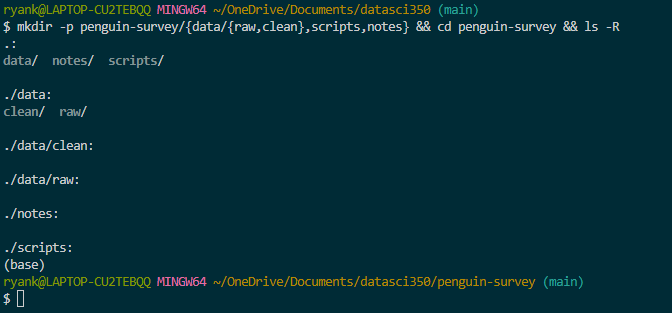

### Task 02

Create the file `notes/README.md` with `touch`. Append the line `# Penguin survey 2026` to it with `echo` and a redirect. Display the file with `cat`.

*Commands and screenshot here.*

touch notes/README.md && echo " Penguin survey 2026" >> notes/README.md && cat notes/README.md
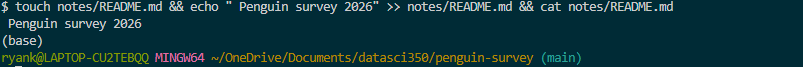

### Task 03

Create the five daily log files `data/raw/day1.csv` through `data/raw/day5.csv` with a single command. Use brace expansion.

*Commands and screenshot here.*

touch data/raw/day{1..5}.csv
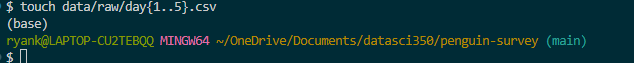

### Task 04

Download the field observations into `data/raw`. Run this command from the `penguin-survey` directory:

```bash
curl -o data/raw/observations.txt https://raw.githubusercontent.com/danilofreire/datasci350/main/assignments/data/observations.txt
```

Verify the download with `ls -lh data/raw`. The file size appears in the output.

*Commands and screenshot here.*

curl -o data/raw/observations.txt https://raw.githubusercontent.com/danilofreire/datasci350/main/assignments/data/observations.txt && ls -lh data/raw
![image.png](attachment:image.png)

### Task 05

Show the first five lines of `data/raw/observations.txt` with `head`, then the last three lines with `tail`. Both commands take the `-n` option.

*Commands and screenshot here.*

head -n 5 data/raw/observations.txt && tail -n 3 data/raw/observations.txt
![image.png](attachment:image.png)

### Task 06

Print every line of `observations.txt` that contains "Gentoo" using `grep`. Then count those lines with `grep -c`, which prints the number of matching lines instead of the lines themselves.

*Commands and screenshot here.*

grep "Gentoo" data/raw/observations.txt && grep -c "Gentoo" data/raw/observations.txt
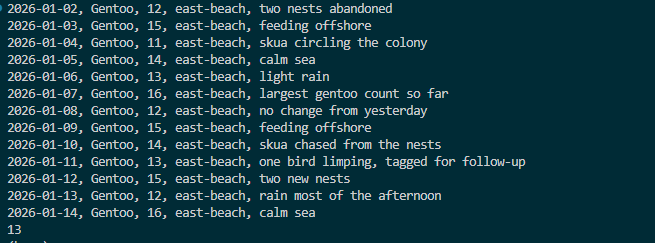

### Task 07

Warning: `rm` deletes files permanently. There is no recycle bin on the command line. Check the file name before you press Enter.

Copy `data/raw/observations.txt` to `data/clean/observations-backup.txt`. Rename `data/raw/day5.csv` to `data/raw/day05-final.csv`. Delete `data/raw/day4.csv`.

*Commands and screenshot here.*

cp ./data/raw/observations.txt ./data/clean/observations-backup.txt && mv ./data/raw/day5.csv ./data/raw/day05-final.csv && rm data/raw/day4.csv
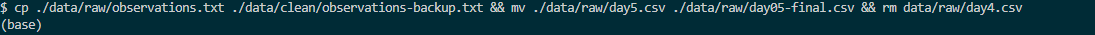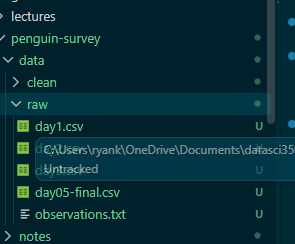

### Task 08

Find every `.csv` file under `data/` with one `find` command. Then find all directories inside `penguin-survey` with a second `find` command. Hint: lecture 04 covered the `-name` and `-type` options.

*Commands and screenshot here.*

find data -type f -name "*.csv" && find . -type d
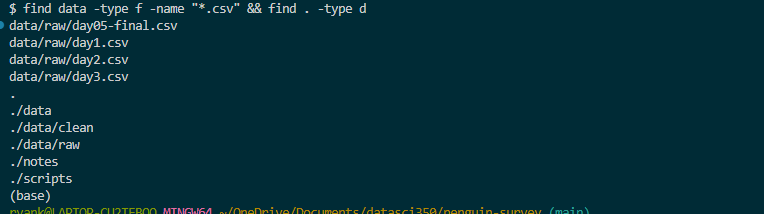

### Task 09

Use `sed` to replace every occurrence of "Adelie" with "Adélie" in `observations.txt`, saving the result to `data/clean/observations-accents.txt`. Do not modify the original file: use a redirect, not `-i`. Display the first three lines of the new file to confirm the change.

*Commands and screenshot here.*

sed 's/Adelie/Adélie/g' data/raw/observations.txt > data/clean/observations-accents.txt && head -n 3 data/clean/observations-accents.txt
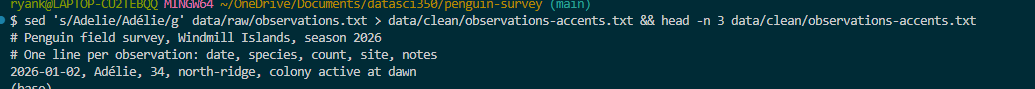

### Task 10

Use `man ls` to find the flag that sorts files by size, largest first. Run `ls -l` on `data/raw` with that flag. Which file is the largest?

*Commands and screenshot here.*

observations.txt because it is at the top
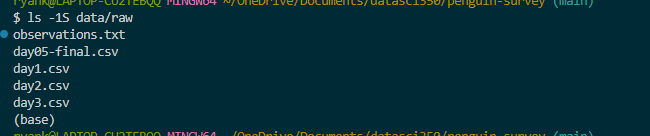

### Task 11

Explain, part by part, what the following pipeline does. Two or three sentences are enough. Do not run it first: predict, then run it to check yourself.

```bash
cat data/raw/observations.txt | grep -i "chinstrap" | wc -l > notes/chinstrap.txt
```

*Commands and screenshot here.* 

reads and prints observations.txt in output and then searches for lines with chinstrap with no consideration for capitalization due to -i which is piped into wc which counts lines recieved and then overwrites it into notes/chinstrap.txt.

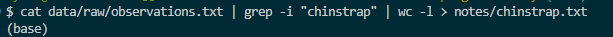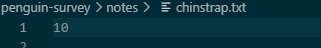

### Task 12

Run `ls -lh data/raw` three ways from a Jupyter notebook: with the `!` prefix, in a `%%bash` cell, and with Python's `subprocess` module. The three cells below show the skeleton of each approach; complete and run them. Screenshots are not needed for this task, since the notebook shows the output.

#### How to run command line commands in a Jupyter notebook

There are three common approaches. Complete each cell below with the Task 12 command and run it.

1. The `!` prefix executes one line as a shell command:

In [24]:
# Complete: run ls -lh on data/raw with the ! prefix
!ls -lh data/raw

'ls' is not recognized as an internal or external command,
operable program or batch file.


2. The `%%bash` magic runs the whole cell as a bash script:

In [20]:
%%bash
ls -lh data/raw

Couldn't find program: 'bash'


3. Python's `subprocess` module runs commands from Python code:

In [26]:
import subprocess
# Complete the list: one string per part of the command
result = subprocess.run(["ls", "-lh", "data/raw"], capture_output=True, text=True)
print(result.stdout)

FileNotFoundError: [WinError 2] The system cannot find the file specified